In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/clean_incidents.csv"
)

df.head()

,incident_id,date,year,month,airline,airline_region,airline_country,aircraft_type,aircraft_category,manufacturer,...,primary_cause,is_fatal,fatalities,occupants_onboard,injuries,hull_loss,damage_category,investigation_status,engines,seats_config
0,AV000001,2002-02-27,2002,2,Kenya Airways,Africa,Kenya,HAVILLAND Twin Otter,Turboprop,De Havilland,...,loading error,0,0,5,0,0,NaN,Inconclusive,2,20
1,AV000002,1985-01-18,1985,1,TAP Air Portugal,Europe,Portugal,Boeing 777-300ER,Widebody,Boeing,...,manufacturing,0,0,311,51,0,Minor,Probable cause determined,2,396
2,AV000003,2008-08-23,2008,8,American Airlines,NorthAmerica,USA,Boeing 767-400,Widebody,Boeing,...,crew error,1,183,245,0,1,Destroyed,Probable cause determined,2,245
3,AV000004,1997-12-28,1997,12,ASKY Airlines,Africa,Togo,Fokker 100,Regional,Fokker,...,navigation,0,0,45,9,0,Minor,Inconclusive,2,107
4,AV000005,1973-08-05,1973,8,Air France,Europe,France,Boeing 720,Narrowbody,Boeing,...,weather,1,40,127,0,1,Destroyed,Probable cause determined,4,149


In [9]:
df["aircraft_type"]\
.value_counts()\
.head(20)

aircraft_type
COMAC C919                 355
Boeing 737-800             353
Boeing 737 MAX 8           352
Boeing 747-100             350
Fokker F28                 349
Boeing 737 MAX 9           348
Britten-Norman Islander    348
Vickers VC10               348
Boeing 777-200             347
Fokker 70                  343
Airbus A319                341
Airbus A350-900            336
CASA CN-235                335
Bombardier CRJ-900         333
Airbus A320neo             332
ATR 72-600                 331
Hawker Siddeley Trident    331
Boeing 727-200             331
Ilyushin Il-76             330
Airbus A220-300            329
Name: count, dtype: int64

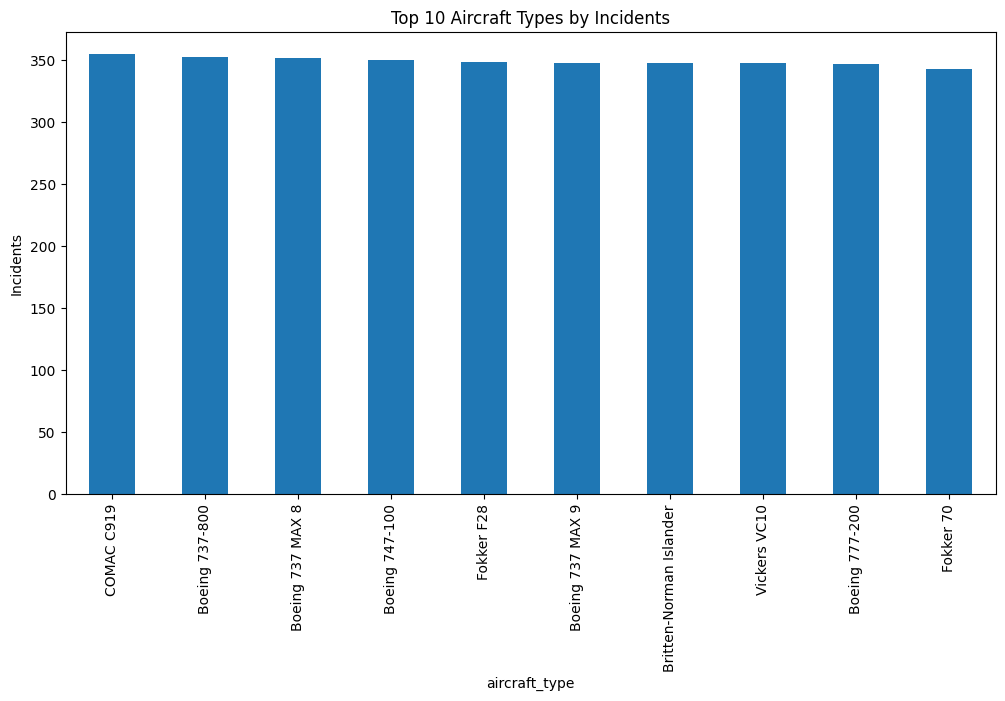

In [10]:
top_aircraft = (
    df["aircraft_type"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_aircraft.plot(
    kind="bar"
)

plt.title(
    "Top 10 Aircraft Types by Incidents"
)

plt.ylabel("Incidents")

plt.show()

In [11]:
manufacturer_fatalities = (

    df.groupby(
        "manufacturer"
    )["fatalities"]

    .sum()

    .sort_values(
        ascending=False
    )

)

manufacturer_fatalities.head(10)

manufacturer
Boeing               119327
Airbus                92208
McDonnell Douglas     23323
Ilyushin              10373
Embraer                8636
Tupolev                7454
Fokker                 7423
Lockheed               7240
Vickers                6647
Bombardier             5731
Name: fatalities, dtype: int64

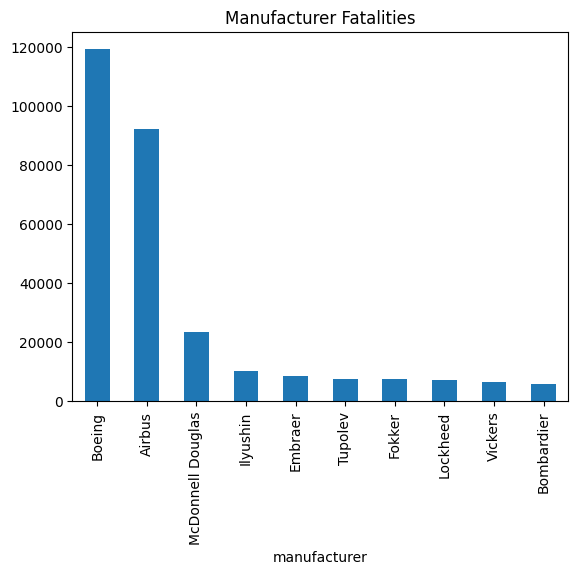

In [12]:
manufacturer_fatalities.head(10).plot(
    kind="bar"
)

plt.title(
    "Manufacturer Fatalities"
)

plt.savefig(
    "../visuals/manufacturer_analysis.png",
    bbox_inches="tight"
)

plt.show()

In [13]:
aircraft_risk = (

    df.groupby(
        "aircraft_type"
    )

    .agg({

        "fatalities":"sum",

        "incident_id":"count"

    })

)

aircraft_risk["risk_score"] = (

    aircraft_risk["fatalities"]

    /

    aircraft_risk["incident_id"]

)

aircraft_risk.sort_values(
    "risk_score",
    ascending=False
).head(15)

,fatalities,incident_id,risk_score
aircraft_type,,,
Airbus A380,17698,316,56.006329
Boeing 747-8,11292,297,38.020202
Boeing 747-400,11491,308,37.308442
Boeing 777-300ER,11521,312,36.926282
Airbus A350-900,10029,336,29.848214
Airbus A300,8113,289,28.072664
Airbus A340-300,8885,317,28.028391
Airbus A330neo,9023,322,28.021739
Boeing 787-9,7940,298,26.644295


In [14]:
print(
"""
Aircraft Analysis Findings

1. Most incident-prone aircraft identified.
2. Manufacturer fatality comparison completed.
3. Aircraft risk scores calculated.
4. High-risk aircraft models highlighted.
"""
)


Aircraft Analysis Findings

1. Most incident-prone aircraft identified.
2. Manufacturer fatality comparison completed.
3. Aircraft risk scores calculated.
4. High-risk aircraft models highlighted.

